In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

In [29]:
df = pd.read_csv("/content/mnist_train.csv")

In [30]:
print(df.shape)

(60000, 785)


In [31]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
X = df.drop("label", axis=1)
y = df["label"]

print("Images:", X.shape)

Images: (60000, 784)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_unused = train_test_split(
    X, test_size=0.90, random_state=42
)

X_train = X_train.values.astype("float32")
print(X_train.shape)

(6000, 784)


In [45]:
X_train = (X_train - 127.5) / 127.5
X_train = X_train.reshape(-1, 28, 28, 1)

print(X_train.shape)

(6000, 28, 28, 1)


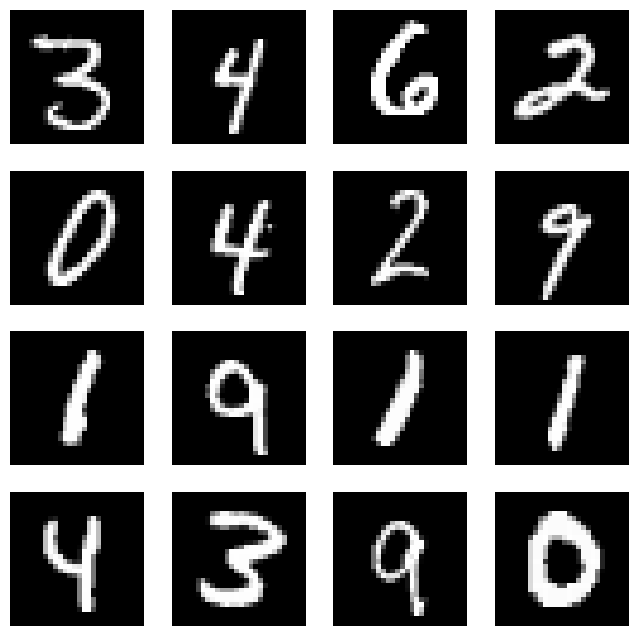

In [46]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow((X_train[i] + 1) / 2, cmap="gray")
    plt.axis("off")
plt.show()

In [47]:
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE)

In [48]:
generator = tf.keras.Sequential([
    layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((7, 7, 256)),

    layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(1, (5,5), padding="same", activation="tanh")
])

generator.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [49]:
discriminator = tf.keras.Sequential([
    layers.Conv2D(64, (5,5), strides=(2,2), padding="same", input_shape=[28,28,1]),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Conv2D(128, (5,5), strides=(2,2), padding="same"),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1)
])

discriminator.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

g_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
d_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

In [51]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        generated = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated, training=True)

        g_loss = loss_fn(tf.ones_like(fake_output), fake_output)
        d_loss = (
            loss_fn(tf.ones_like(real_output), real_output) +
            loss_fn(tf.zeros_like(fake_output), fake_output)
        )

    g_grad = gt.gradient(g_loss, generator.trainable_variables)
    d_grad = dt.gradient(d_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(g_grad, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(d_grad, discriminator.trainable_variables))

    return g_loss, d_loss

In [54]:
EPOCHS = 1

for epoch in range(EPOCHS):
    for i, images in enumerate(train_dataset):
        g_loss, d_loss = train_step(images)

        if i % 20 == 0:
            print(
                f"Epoch {epoch+1} | Batch {i} | "
                f"G Loss: {g_loss:.4f} | D Loss: {d_loss:.4f}"
            )

Epoch 1 | Batch 0 | G Loss: 0.5718 | D Loss: 1.4465
Epoch 1 | Batch 20 | G Loss: 0.6204 | D Loss: 1.3933
Epoch 1 | Batch 40 | G Loss: 0.6009 | D Loss: 1.4743


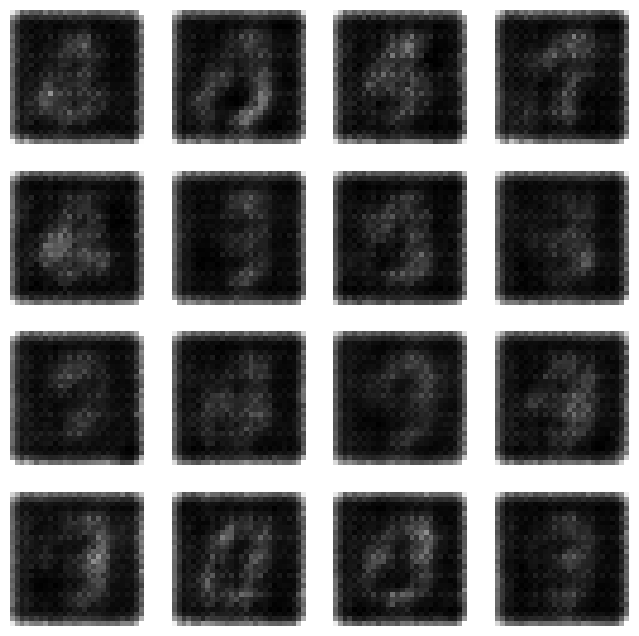

In [55]:
noise = tf.random.normal([16, 100])
generated_images = generator(noise, training=False)

plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow((generated_images[i] + 1) / 2, cmap="gray")
    plt.axis("off")
plt.show()

In [56]:
generator.save("mnist_gan_generator.keras")
print("Generator saved successfully!")

Generator saved successfully!


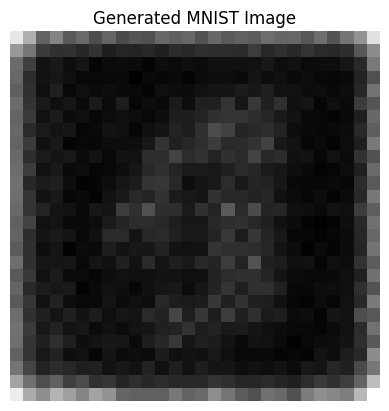

In [57]:
noise = tf.random.normal([1, 100])
new_image = generator(noise, training=False)[0]

plt.imshow((new_image + 1) / 2, cmap="gray")
plt.axis("off")
plt.title("Generated MNIST Image")
plt.show()